# **Pre-Trained Model 3 - DenseNet**

DenseNet was selected as the third pretrained architecture for the modelling phase. Unlike the previous two models, this notebook evaluates **three variants** - DenseNet121, DenseNet169 and DenseNet201. We applu them under identical conditions, allowing an internal comparison before the global evaluation. <br>

### **Why DenseNet?**

DenseNet (Densely Connected Convolutional Network) follows a fundamentally different connectivity pattern from EfficientNetB0 and MobileNetV2. Rather than passing features sequentially from layer to layer, each layer receives the feature maps of **all preceding layers** as input and passes its own to all subsequent ones. This dense connectivity has two important consequences: it encourages strong feature reuse throughout the network, and it naturally alleviates the vanishing gradient problem without requiring residual shortcuts.

### **Why test three variants?**

The three variants differ only in depth (121, 169 and 201 layers), with progressively more dense blocks and a larger number of unfrozen layers in phase 2 (50, 70 and 85 respectively). Since DenseNet's parameter count grows more modestly with depth than other architectures (due to feature reuse), testing all three is feasible without a strong prior risk of overfitting. This **internal comparison** lets us **assess** whether **additional depth provides meaningful gains on this dataset**, or whether the smaller variant is sufficient.

#### Dataset-specific considerations:

- **Feature reuse and small datasets**: DenseNet's dense connectivity means that low-level features learned early in the network, such as  colour distributions, edge orientations, texture gradients, remain directly accessible to deeper layers. This is particularly valuable when training data is limited, as it reduces the pressure on each individual layer to independently re-learn representations already captured elsewhere;
- **Minority class sensitivity**: The dense feature propagation also means that subtle discriminative signals, relevant for visually similar but clinically distinct lesion types (e.g. MEL vs NV), are less likely to be lost through successive transformations, which is a relevant property given the dataset's class imbalance and inter-class visual similarity.

### Imports

In [1]:
import tensorflow as tf
#prevent TF from grabbing all GPU memory at once
gpus = tf.config.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

In [2]:
from tensorflow.keras import mixed_precision

# Tell Keras to use float16 for memory, but keep float32 for numeric stability in the loss
policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)

print('Compute dtype: %s' % policy.compute_dtype)
print('Variable dtype: %s' % policy.variable_dtype)

INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA GeForce RTX 3060 Laptop GPU, compute capability 8.6
Compute dtype: float16
Variable dtype: float32


In [ ]:
import os
import sys
import keras.applications
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize
from keras.applications.densenet import preprocess_input


if os.getcwd().endswith('models'):
    os.chdir('..')
    
from utils.utils_model import *
from utils.utils_augmentation import *
from utils.utils_preproc import *

In [4]:
from tensorflow.keras import layers, Input, Model
from tensorflow.keras.applications import DenseNet121

In [5]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
print("GPUs available:", gpus)
print("TF built with CUDA:", tf.test.is_built_with_cuda())
print("GPU available to TF:", tf.test.is_gpu_available())  # deprecated but still works

GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
TF built with CUDA: True
Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.
GPU available to TF: True


### Configuration

In [ ]:
# Load label mapping first — everything else depends on it
with open("label2idx.json", "r") as f:
    label2idx = json.load(f)

N_CLASSES  = len(label2idx)
BATCH_SIZE = 32

train_df = pd.read_csv('data/augmented_metadata.csv')
val_df   = pd.read_csv('data/val_split.csv')
test_df  = pd.read_csv('data/test_split.csv')

# Normalise column names and encode labels for all splits
for df in [train_df, val_df, test_df]:
    if 'cleaned_path' in df.columns and 'image_path' in df.columns:
        df.drop(columns=['image_path'], inplace=True)
    df.rename(columns={'cleaned_path': 'image_path'}, inplace=True)
    df['dx_encoded'] = df['dx'].map(label2idx).astype(int)

# Build datasets
train_ds = make_dataset(train_df, shuffle=True, repeat=True, preprocess_fn=preprocess_input)
val_ds   = make_dataset(val_df, preprocess_fn=preprocess_input)
test_ds  = make_dataset(test_df, preprocess_fn=preprocess_input)

STEPS_PER_EPOCH = len(train_df) // BATCH_SIZE
class_weights_dict = make_class_weights(train_df)

In [7]:
print(f"Steps per epoch: {STEPS_PER_EPOCH}")
print(f"Class weights: {class_weights_dict}")

Steps per epoch: 394
Class weights: {0: 1.4493569131832797, 1: 1.2340862422997947, 2: 0.8370473537604457, 3: 2.504166666666667, 4: 0.8727008712487899, 5: 0.42867332382310985, 6: 2.3415584415584414}


### **Model** Configuration

In [8]:
def build_densenet():
    """
    Builds a DenseNet model with a frozen pretrained base and a
    custom classifier head. The same head architecture is used for
    all three variants so results are directly comparable.

    Parameters
    ----------
    application : keras.applications class
        One of DenseNet121, DenseNet169, DenseNet201.
    unfreeze_from : int
        Negative index into base.layers — layers from this index
        onward are unfrozen in Phase 2.
    """
    # FIX: Use the 'application' parameter passed to the function 
    # instead of the hardcoded 'keras.applications.Densenet'
    base = keras.applications.DenseNet121(
        include_top=False,
        weights="imagenet",
        input_shape=(224, 224, 3),
        pooling=None
    )
    base.trainable = False

    inputs  = Input(shape=(224, 224, 3))
    x = base(inputs, training=False)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    outputs = keras.layers.Dense(N_CLASSES)(x)
    return keras.Model(inputs, outputs, name="densenet_121")

Model: "densenet_121"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 densenet121 (Functional)    (None, 7, 7, 1024)        7037504   
                                                                 
 global_average_pooling2d (G  (None, 1024)             0         
 lobalAveragePooling2D)                                          
                                                                 
 dropout (Dropout)           (None, 1024)              0         
                                                                 
 dense (Dense)               (None, 256)               262400    
                                                                 
 batch_normalization (BatchN  (None, 256)              1024      
 ormalization)                                        

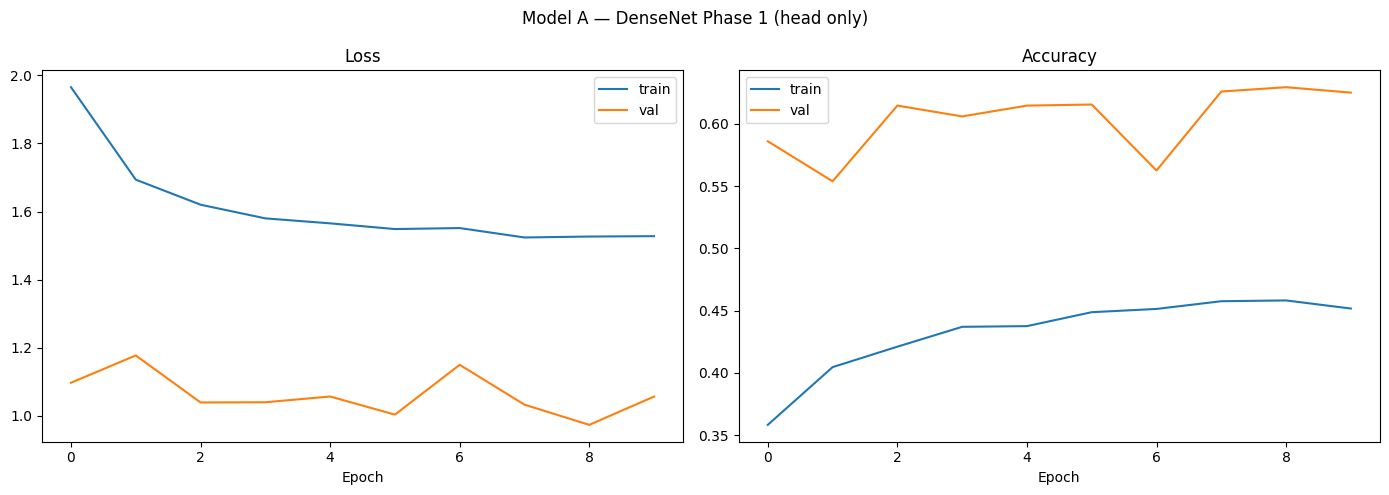

In [9]:
# phase 1: head only
model_pt1 = build_densenet() # Model Pre-Trained 1
model_pt1.summary()

model_pt1.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy", BalancedAccuracy(N_CLASSES)]
)

my_callbacks = get_callbacks(
    checkpoint_path="checkpoints/model_DN_phase1.weights.h5",
    model=model_pt1,      # <--- Pass your model here
    max_diff=0.15,        # <--- Your 15% limit
    patience_es=6, 
    patience_lr=3
)

history1_pt1 = model_pt1.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    steps_per_epoch=STEPS_PER_EPOCH,
    class_weight=class_weights_dict,
    callbacks=my_callbacks
)

plot_history(history1_pt1, "Model A — DenseNet Phase 1 (head only)")

In [14]:
# Create a fresh, untrained model using your blueprint
model_pt2 = build_densenet()

In [15]:
# Load the Phase 1 weights from the hard drive
model_pt2.load_weights("checkpoints/model_DN_phase1.weights.h5")
print("Phase 1 weights loaded successfully!")

Phase 1 weights loaded successfully!


Epoch 1/50
394/394 [==============================] - ETA: 0s - loss: 0.8474 - accuracy: 0.6681 - balanced_accuracy: 0.6912
Epoch 1: val_loss improved from inf to 0.93873, saving model to checkpoints\model_DN_phase2.weights.h5
394/394 [==============================] - 154s 269ms/step - loss: 0.8474 - accuracy: 0.6681 - balanced_accuracy: 0.6912 - val_loss: 0.9387 - val_accuracy: 0.6528 - val_balanced_accuracy: 0.5568 - lr: 1.0000e-05
Epoch 2/50
394/394 [==============================] - ETA: 0s - loss: 0.7808 - accuracy: 0.6968 - balanced_accuracy: 0.7215
Epoch 2: val_loss improved from 0.93873 to 0.86565, saving model to checkpoints\model_DN_phase2.weights.h5
394/394 [==============================] - 119s 301ms/step - loss: 0.7808 - accuracy: 0.6968 - balanced_accuracy: 0.7215 - val_loss: 0.8657 - val_accuracy: 0.6701 - val_balanced_accuracy: 0.5700 - lr: 1.0000e-05
Epoch 3/50
394/394 [==============================] - ETA: 0s - loss: 0.7194 - accuracy: 0.7168 - balanced_accuracy: 0

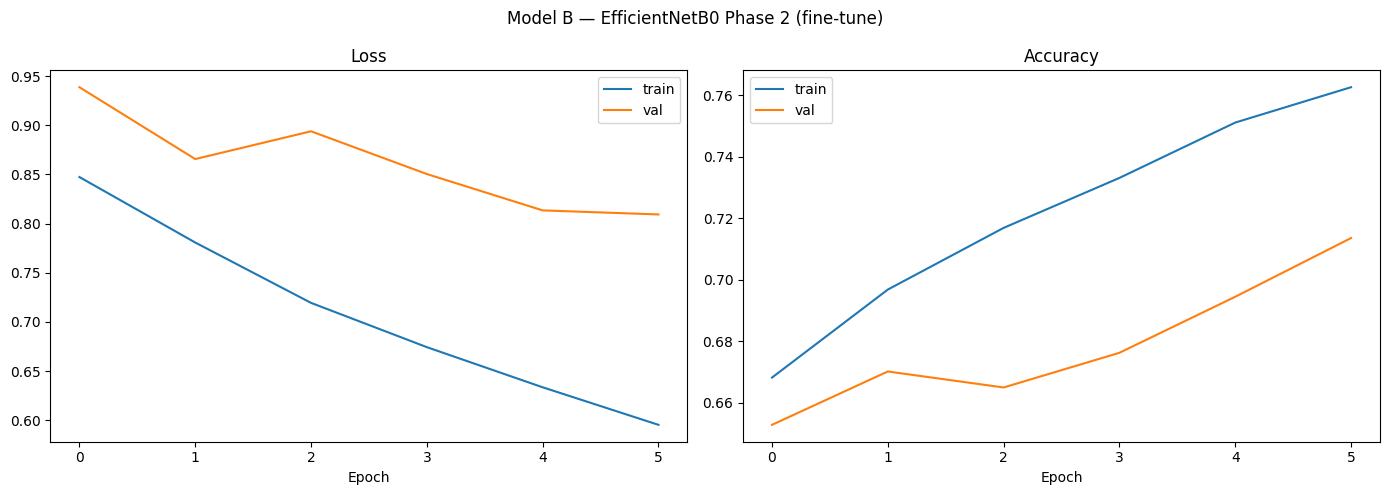


  Model B — EfficientNetB0 — classification report
              precision    recall  f1-score   support

       akiec       0.35      0.59      0.44        29
         bcc       0.59      0.68      0.63        65
         bkl       0.49      0.45      0.47       109
          df       0.30      0.38      0.33         8
         mel       0.35      0.66      0.46       127
          nv       0.93      0.76      0.84       778
        vasc       0.42      1.00      0.59        10

    accuracy                           0.71      1126
   macro avg       0.49      0.64      0.54      1126
weighted avg       0.78      0.71      0.73      1126

  *** Melanoma recall: 0.661 ***  (clinical priority metric)


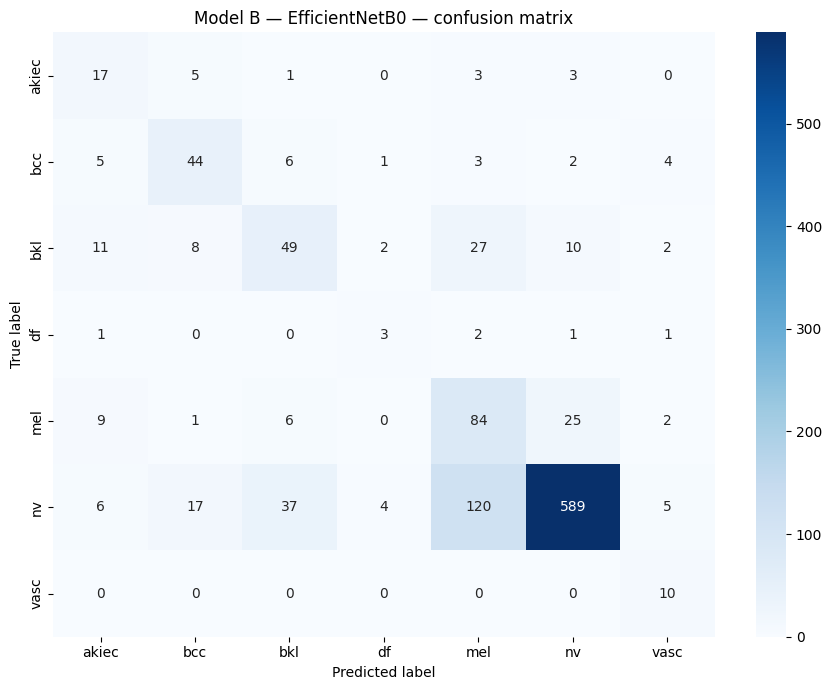


  Macro AUC-ROC: 0.9254


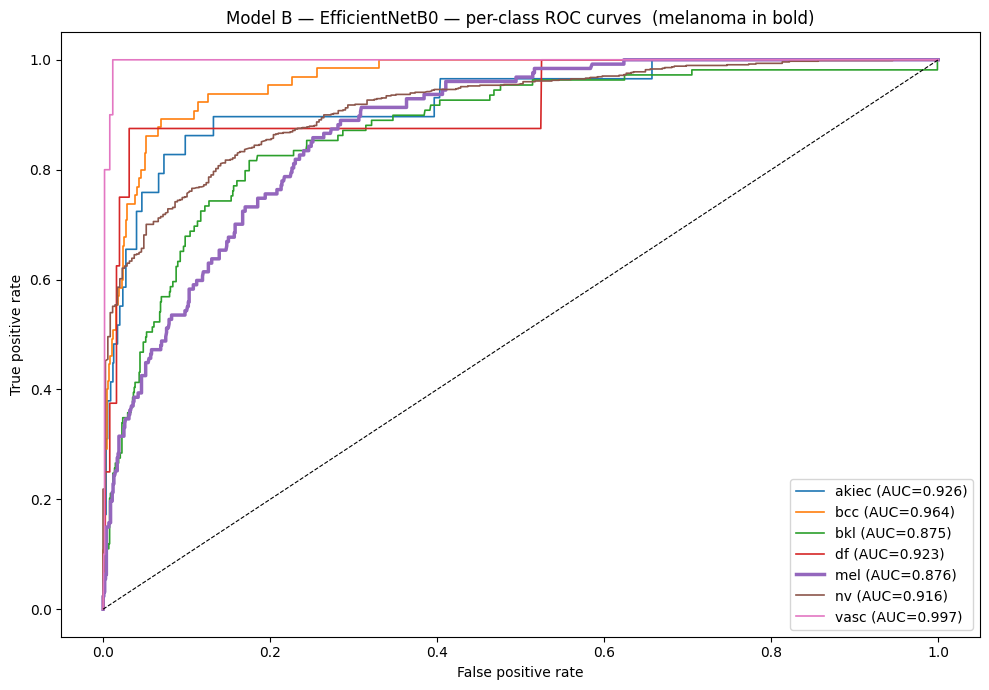

In [17]:
# Phase 2: Fine-tune top layers
base_b = model_pt2.get_layer('densenet121')
base_b.trainable = True

for layer in base_b.layers:
    if isinstance(layer, keras.layers.BatchNormalization):
        layer.trainable = False

model_pt2.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy", BalancedAccuracy(N_CLASSES)])

my_callbacks = get_callbacks(
    checkpoint_path="checkpoints/model_DN_phase2.weights.h5",
    model=model_pt2,    
    max_diff=0.35,       
    patience_es=10, 
    patience_lr=5
)

history2_b0 = model_pt2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    steps_per_epoch=STEPS_PER_EPOCH,
    class_weight=class_weights_dict,
    callbacks=my_callbacks
)

plot_history(history2_b0, "Model B — DenseNet121 Phase 2 (fine-tune)")
results_b = evaluate_model(model_pt2, test_ds, label2idx, "Model B — DenseNet121")

### Automated training Loop
Stores results from all three variants for the final comparison.


In [ ]:
for label, application, unfreeze_from in DENSENET_CONFIGS:
    print(f"\n{'='*60}")
    print(f"  Training {label}")
    print(f"{'='*60}\n")

    safe_label = label.replace(" ", "_").replace("—", "").replace("/", "")
    ckpt_phase1 = f"checkpoints/{safe_label}_phase1.weights.h5"
    ckpt_best   = f"checkpoints/{safe_label}_best.weights.h5"

    # Build model (Fully unfrozen by default now)
    model, base, unfreeze_idx = build_densenet(application, unfreeze_from)

    model.compile(
        optimizer=keras.optimizers.Adam(1e-5),
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=["accuracy", BalancedAccuracy(N_CLASSES)]
    )

    print(f"Training fully unfrozen ({label})")

    history_p1 = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=20,
        steps_per_epoch=STEPS_PER_EPOCH,
        class_weight=class_weights_dict,
        callbacks=get_callbacks(ckpt_phase1, patience_es=6, patience_lr=3)
    )
    plot_history(history_p1, f"{label} — Fully Unfrozen")

    
    # ── Evaluate ──────────────────────────────────────────────────────────
    results = evaluate_model(model, test_ds, label2idx, label)
    densenet_results[label]   = results
    densenet_histories[label] = {"full_train": history}

    print(f"\n  {label} done — AUC: {results['macro_auc']:.4f} | "
          f"Mel recall: {results['mel_recall']:.4f}\n")


### DENSENET INTERNAL COMPARISON 
Compare the three variants against each other before the global summary.

In [ ]:
plot_comparison(densenet_results)

### FULL PIPELINE COMPARISON

In [ ]:
all_results = {
    "A — Custom CNN": results_a,
    "B — EfficientNetB0": results_b,
    "C — MobileNetV2": results_c,
    **densenet_results,
}

plot_comparison(all_results)